Théo BASSERAS
ID Etudiant: 2500139

### Partie 0 — Setup & chargement des données (5 min)

In [343]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

np.random.seed(123)
plt.rcParams["figure.figsize"] = (7.5, 4.5)
plt.rcParams["axes.grid"] = True


In [344]:
# Cellule 1 — Chargement des données Rdatasets (mêmes données que les packages R ismev/texmex)


port = pd.read_csv("portpirie_yearly_maxima.csv",index_col=0)
rain = pd.read_csv("daily_rainfall_data.csv",index_col=0)
display(port.head(5))
print()
display(rain.head(5))

,Year,SeaLevel
rownames,,
1,1923,4.03
2,1924,3.83
3,1925,3.65
4,1926,3.88
5,1927,4.01


,daily_rainfall
rownames,
1,0.0
2,2.3
3,1.3
4,6.9
5,4.6


### Partie 1 — Maxima par blocs (Port Pirie) → GEV (35 min)

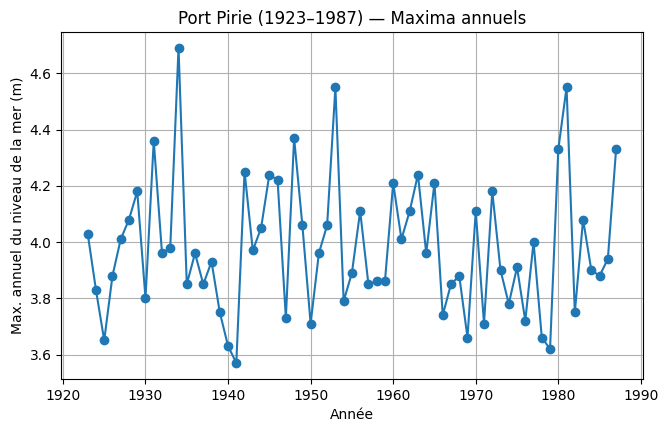

In [345]:
# 1A
fig, ax = plt.subplots()
ax.plot(port["Year"], port["SeaLevel"], marker="o")
ax.set_xlabel("Année"); ax.set_ylabel("Max. annuel du niveau de la mer (m)")
ax.set_title("Port Pirie (1923–1987) — Maxima annuels")
plt.show()



The time series of annual maximum sea levels at Port Pirie shows no dominant long-term trend, establishing a stable baseline for analysis. However, the data exhibits a clear dispersion with a distinct gap separating the bulk of "normal" maxima (clustered between ~3.75m and 4.3m) from the upper tail. It is precisely these visually extreme values above ~4.4m that justify applying Extreme Value Theory (EVT), as this framework is designed to model the probabilistic behavior of these rare, high-impact events, moving beyond describing the central mass of data to quantitatively assess the risk of severe sea-level extremes.

In [346]:
# 1B Fit des paramètres
data_pp = port["SeaLevel"].values
c, loc, scale = stats.genextreme.fit(data_pp)  # MLE ; c = -xi
xi_hat, mu_hat, sigma_hat = -c, loc, scale
print("mu_hat,sigma_hat,gama_hat)=", mu_hat, sigma_hat,xi_hat)


mu_hat,sigma_hat,gama_hat)= 3.874758730628963 0.19803814023673208 -0.05010534785328627


The estimated gamma (shape parameter) is negative but close to zero. With more data, we could determine if it is strictly negative or effectively zero, but for now, we can conclude the tail is light-tailed and potentially has an upper bound. The choice between a model where gamma equals zero (unbounded) or is less than zero (bounded) can be guided by physical reasoning. If we choose gamma=0, it implies that, in theory, there is no physical ceiling to flood heights, water could rise indefinitely. Conversely, choosing gamma<0 posits a finite upper limit, which could be justified by real-world constraints like the height of the surrounding topography or the total volume of water available in the system.

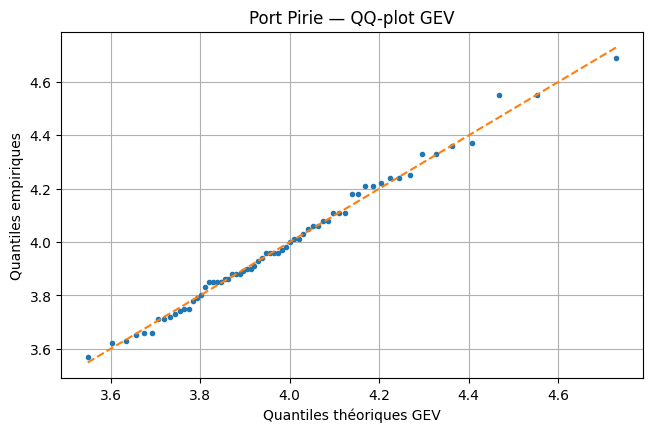

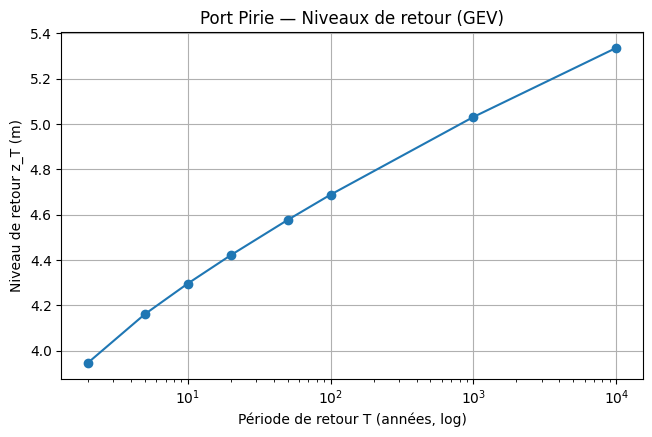

In [347]:
# 1C Diagnostic

# QQ-plot
q = (np.arange(1, len(data_pp)+1) - 0.5) / len(data_pp)
gev_q = stats.genextreme.ppf(q, -xi_hat, loc=mu_hat, scale=sigma_hat)
emp_q = np.sort(data_pp)

plt.figure(); plt.plot(gev_q, emp_q, 'o', ms=3)
mn, mx = min(gev_q.min(), emp_q.min()), max(gev_q.max(), emp_q.max())
plt.plot([mn, mx], [mn, mx], '--')
plt.xlabel("Quantiles théoriques GEV"); plt.ylabel("Quantiles empiriques")
plt.title("Port Pirie — QQ-plot GEV")
plt.show()


T = np.array([2,5,10,20,50,100,1e3,1e4])
p = 1 - 1/T
# z_gev = gev_return_level(p, mu_hat, sigma_hat, xi_hat)
z_gev = stats.genextreme.ppf(p, -xi_hat, loc=mu_hat, scale=sigma_hat)

plt.figure(); plt.plot(T, z_gev, '-o')
plt.xscale("log"); plt.xlabel("Période de retour T (années, log)")
plt.ylabel("Niveau de retour z_T (m)"); plt.title("Port Pirie — Niveaux de retour (GEV)")
plt.show()


Based on the return-level plot, the curve exhibits a characteristic concave-downward shape, which is consistent with a light-tailed distribution (gamma ≈ 0) or a bounded distribution (gamma < 0).

 The extrapolations for high return periods (e.g., T = 100 to 10,000 years) appear plausible as they show a stabilizing pattern, with the return levels increasing at a progressively slower rate (slope 3/2 of 1e3 and 1e4 against 1 for 1e2 to 1e3). This  between suggests the extremes may have a physical upper elimit or don't to infinity too quickly, preventing unrealistic, unbounded growth in projected sea levels, making the model's long-term predictions more credible.
 
We see that there is no clear limit appearing (when we increase the Time T, z_T increases too), this suggests that we z_T is not bounded so matches gamma=0.

### Part 2 Exceedances above a threshold

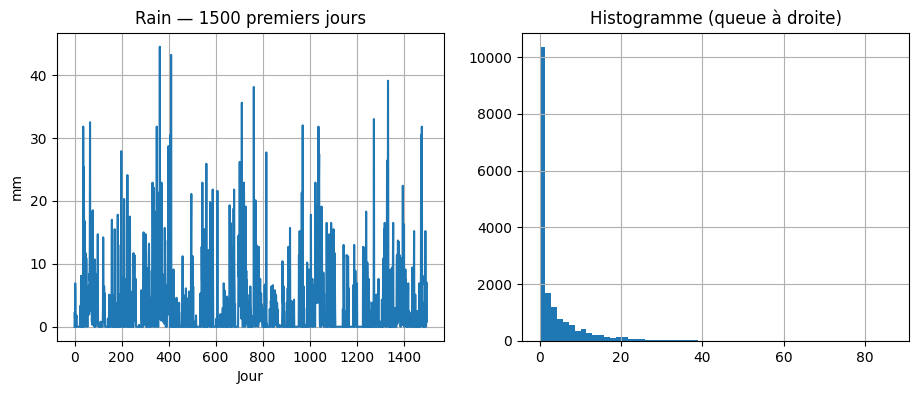

17531

In [348]:
# 2A Vue d'ensemble Rain
x = rain["daily_rainfall"].values
fig, ax = plt.subplots(1,2, figsize=(11,4))
ax[0].plot(x[:1500]); ax[0].set_title("Rain — 1500 premiers jours"); ax[0].set_ylabel("mm"); ax[0].set_xlabel("Jour")
ax[1].hist(x, bins=60); ax[1].set_title("Histogramme (queue à droite)")
plt.show()
len(x)

In the first graph, we can see a clear difference between the extreme values (above 20 mm) and the more typical ones (below 20 mm). These extreme events occur fairly often, which shows up in the histogram as a heavy right tail.

The pronounced right tail suggests that, in the context of extreme value theory, the data is likely to follow a Fréchet distribution.

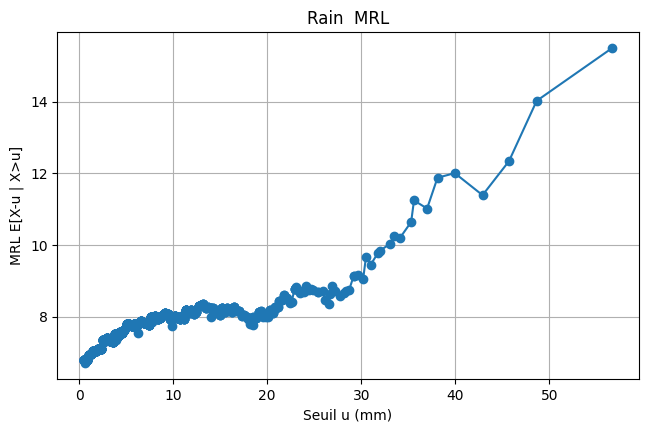

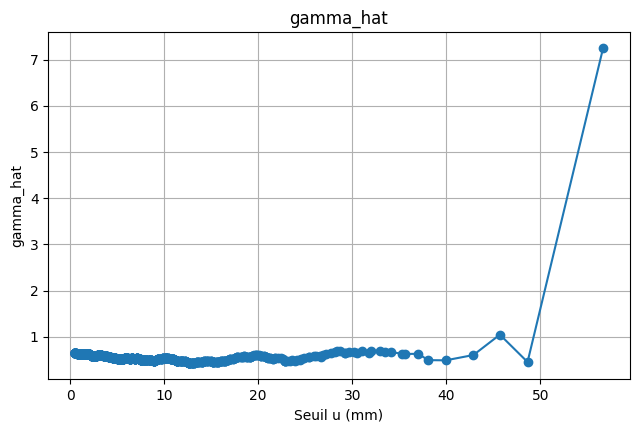

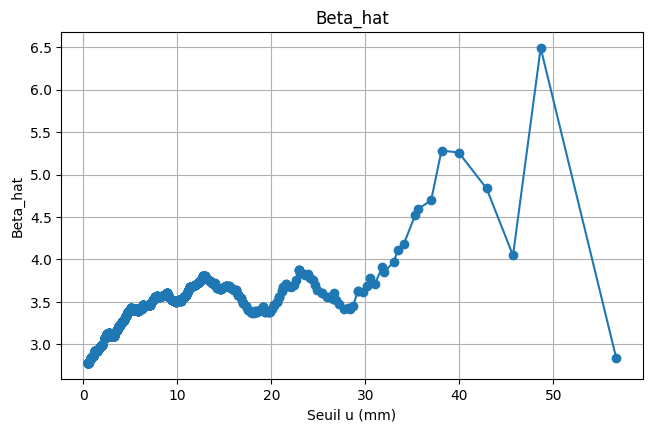

In [349]:
# 2B Mean Residual Life (MRL) + compte d'excès
def mean_residual_life(x, u_grid):
    mrl = []
    C = []
    Scale = []
    for u in u_grid:
        exc = x[x > u] - u
        mrl.append(np.nan if exc.size==0 else exc.mean())
        c, loc, scale = stats.genextreme.fit(exc)
        C.append(np.nan if exc.size==0 else -c)
        Scale.append(np.nan if exc.size==0 else scale)
    return np.array(mrl), np.array(C), np.array(Scale)

u_grid = np.quantile(x, np.linspace(0.50, 0.9995, 1000))
mrl = mean_residual_life(x, u_grid)

fig, ax1 = plt.subplots()
ax1.plot(u_grid, mrl[0], '-o'); ax1.set_xlabel("Seuil u (mm)"); ax1.set_ylabel("MRL E[X-u | X>u]")
plt.title("Rain  MRL")
plt.show()

fig, ax1 = plt.subplots()
ax1.plot(u_grid, mrl[1], '-o'); ax1.set_xlabel("Seuil u (mm)"); ax1.set_ylabel("gamma_hat")
plt.title("gamma_hat")
plt.show()

fig, ax1 = plt.subplots()
ax1.plot(u_grid, mrl[2], '-o'); ax1.set_xlabel("Seuil u (mm)"); ax1.set_ylabel("Beta_hat")
plt.title("Beta_hat")
plt.show()

 


### 2B.2

The presence of a distinct linear zone in the Mean Residual Life (MRL) plot for thresholds above approximately 30mm is a key diagnostic indicating that the tail of the rainfall distribution follows a heavy-tailed Frechet-type regime (corresponding to a positive shape parameter, gamma > 0, in the Generalized Pareto Distribution). This linearity signifies that the expected excess over a threshold increases proportionally with the threshold itself, which is a characteristic behavior of distributions with unbounded heavy tails, suggesting that the rainfall data is prone to producing very extreme, high-magnitude events.

### 2B. 3.

We see that gamma_hat between 0 and 40 mm is stable and then it becomes unstable. 

We see that beta_hat between 0 and 30 mm is stable and then it becomes unstable. However we are looking for the linear relation between beta_hat and gamma which seems to appear only between 0 and 10mm (beta(u)=beta_0+gamma*u)

So after the threshold 30 mm we see that estimators become unstable. This can be due to the fact that after this threshold we do not have enough data to get precise estimation of beta and gamma.
Hence we could take a threshold in between.

So we have to choose between precision (threshold below 10mm) of our estimators and purity (threshold over 30mm) to really study the extreme.
We can take 25 mm as a threshold for instance.

# HOMEWORK FILE

## 2.C

### 2.C.1

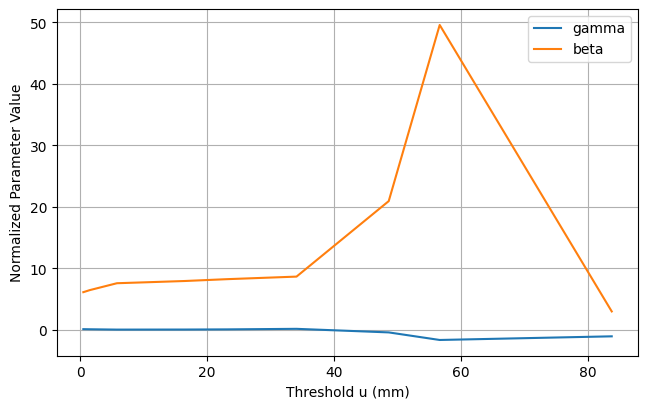

In [350]:
#2C Ajustements GPD pour plusieurs seuils (stabilité)
def fit_gpd_excesses(x, u):
    y = x[x > u] - u
    c, loc, scale = stats.genpareto.fit(y, floc=0.0)  # SciPy: c = xi, scale = beta
    xi, beta = c, scale
    return xi, beta, y

u_candidates = np.quantile(x, [0.5,0.6,0.8,0.9,0.95,0.98,0.995,0.999,0.9995,0.9999])
list_est = []
for u in u_candidates:
    xi, beta, y = fit_gpd_excesses(x, u)
    list_est.append((u, xi, beta))

list_u = [est[0] for est in list_est]
plt.plot(list_u,[est[1] for est in list_est],label="gamma")
plt.plot(list_u,[est[2] for est in list_est],label="beta")
plt.xlabel("Threshold u (mm)")
plt.ylabel("Normalized Parameter Value")
plt.legend()
plt.show()

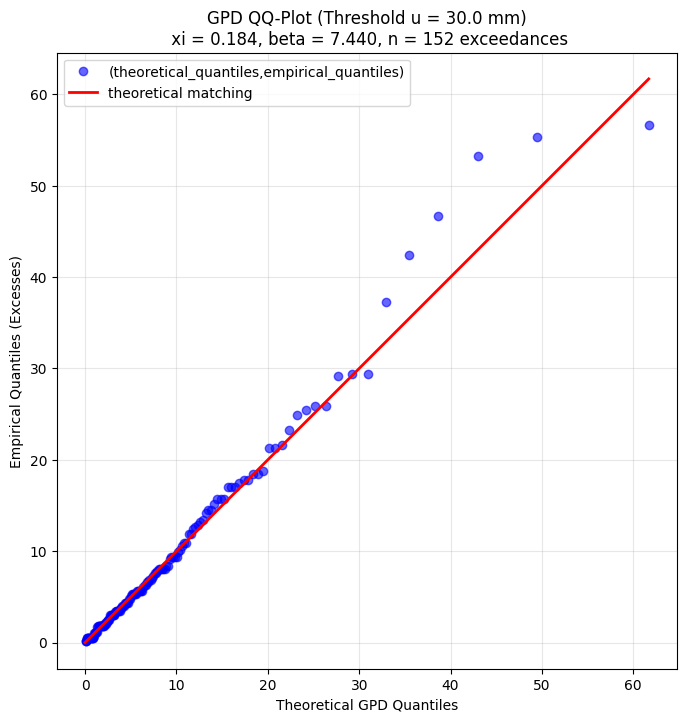

QQ-plot correlation coefficient =  0.9927293402241958
Mean absolute deviation =  0.5712280557969475


In [351]:
import numpy as np
import matplotlib.pyplot as plt

u = 30.0
xi, beta, excesses = fit_gpd_excesses(x, u)

n = len(excesses)
empirical_quantiles = np.sort(excesses)

p = (np.arange(1, n + 1)) / (n + 1)

if abs(xi) < 1e-8:
    theoretical_quantiles = -beta * np.log(1 - p)
else:
    theoretical_quantiles = (beta / xi) * ((1 - p)**(-xi) - 1)

plt.figure(figsize=(8, 8))
plt.plot(theoretical_quantiles, empirical_quantiles, 'bo', alpha=0.6, label="(theoretical_quantiles,empirical_quantiles)")
max_val = max(theoretical_quantiles[-1], empirical_quantiles[-1])
plt.plot([0, max_val], [0, max_val], 'r-', linewidth=2,label="theoretical matching")
plt.xlabel('Theoretical GPD Quantiles')
plt.ylabel('Empirical Quantiles (Excesses)')
plt.title(f'GPD QQ-Plot (Threshold u = {u} mm)\n xi = {xi:.3f}, beta = {beta:.3f}, n = {n} exceedances')
plt.grid(True, alpha=0.3)
plt.axis('equal')
plt.legend()
plt.show()

correlation = np.corrcoef(theoretical_quantiles, empirical_quantiles)[0, 1]
print("QQ-plot correlation coefficient = ",correlation)

deviations = empirical_quantiles - theoretical_quantiles
print("Mean absolute deviation = ",np.mean(np.abs(deviations)))

### 2.C.2

The QQ plot reveals a good GPD fit for moderate excesses (0-10mm above the 30mm threshold) where points align closely with the theoretical line, while medium excesses (10-30mm) show reasonable fit with some dispersion. 

However, for the largest excesses (>30mm above threshold), the empirical quantiles systematically deviate above the line, indicating the model underestimates the most extreme rainfall events. This tail divergence is likely due to insufficient data in the extreme upper tail rather than a fundamental distributional change, highlighting the challenge of precisely characterizing the very extremes of the rainfall distribution with the available sample size.

Hence we recover our 3 zones identified in the previous parts.

### 2.C.3

In [352]:
import numpy as np

T_obs=100


lambda_hat = len(excesses) / len(x)
if abs(xi) < 1e-8:  # gamma = 0 case
    zT = u + beta * np.log(lambda_hat * T_obs)
else:  # gamma != 0 case
    zT = u + (beta / xi) * ((lambda_hat * T_obs)**xi - 1)
    
print("It takes", T_obs,"days in expectation to get rainfall of ",zT, "mm")


It takes 100 days in expectation to get rainfall of  28.952310015886443 mm


### 2.C.3

#### 2.C.3.a

$$P(Y>z_T)= \frac{1}{T} \implies (1+\gamma \frac{z_T}{\beta})^{-\frac{1}{\gamma}} = \frac{1}{T} \implies z_T=\frac{\beta}{\gamma} (T^{\gamma} -1)$$

#### 2.C.3.b

Let's note $$p= P(X_k>z_T)$$

Since $X_i$ are i.i.d., $\tau_{z_T}$ is the first time we observe $X_t > z_T$:

$$
P(\tau_{z_T} = k) = P\left(\min\{t \in \mathbb{N} : X_t > z_T\} = k\right) = P\left(\bigcap_{i=1}^{k-1} \{X_i \leq z_T\} \cap \{X_k > z_T\}\right) = (1-p)^{k-1}p, \quad for \quad k \in \mathbb{N}
$$
So $\tau_{z_T}$ follows a Geometric distribution with success probability $p$.

#### 2.C.3.c

Since we have a geometric law its expectation is :
$$\mathbb{E}(\tau_{z_T}) = \frac{1}{p} = \frac{1}{P(X_k>z_T)} $$

$z_T$ is called the return level associated with period T because the expected waiting time between exceedances of $z_T$ is $T$

This means:
- We expect to see rainfall exceeding $z_T$ once every $T$ days on average
- $T$ is the expected time one would typically wait to observe a value above $z_T$
- $z_T$ represents the typical height exceeded over a period $T$ in expectation

Simply put: if we wait for $T$, we should (in expectation) observe at least one exceedance of $z_T$.

#### 2.C.3.d

Let's take $p_u = P(X > u)$ be the probability of exceeding the threshold.


We suppose here that the maxima of X belongs to a domain of attraction $\gamma$. Then using the theorem 2.1.1, where sigma is a constant (t fixed, here called beta) we get that $P(\frac{X -u}{\beta} > \frac{z_T - u}{\beta} \mid X > u) = P(Z>\frac{z_T - u}{\beta}) = P(Y > z_T - u)$ where according to the theorem 2.1.1 Z follows a GPD($\gamma$,1) hence Y follows GPD($\gamma$,$\beta$)

Hence;
$$\frac{1}{T} = P(X > z_T) =  p_u \cdot P(X -u > z_T - u \mid X > u) = p_u \cdot P(Y > z_T - u)$$


Let's solve 

$$
\begin{align*}
\left(1 + \gamma \frac{z_T - u}{\beta}\right)^{-1/\gamma} &= \frac{1}{p_u T} \\
1 + \gamma \frac{z_T - u}{\beta} &= (p_u T)^{\gamma} \\
z_T &= u + \frac{\beta}{\gamma} \left[(p_u T)^{\gamma} - 1\right]
\end{align*}
$$




In [353]:
u=30
T = 100

xi, beta, excesses = fit_gpd_excesses(x, u)

p_u=len(x[x>u])/len(x)

z_T = u + (beta/xi) *((p_u*T)**(xi)-1)
print("z_"+ str(T )+" = ", z_T, "mm")

z_100 =  28.952310015886443 mm


Hence we recover the previous formula from the TP and get the same result.

### 2.D

#### 2.D.1

We can use the block maxima method. This method consist in dividing our graph into windows and in each window look only at the maximum.

Here we want to estimate the expected height return for a time return T. So we have to take our window size of size T to conclude on the expected return for a waiting time T (suppose we take another window size if the size is bigger than T we could not conclude on z_T and if too small we could do mean but less precise or max but this would be the same as window of size T).

But now we have to choose our step between each window. In other words we have to decide which distance will be between the first height of the window k (x[$\alpha_k$]) and the first value of the window k+1 (x[$\alpha_{k}+1$]), r = $\alpha_{k+1} -\alpha_{k}$ where is the distance between two windows.
Hence, we have $r \in [1,T]$ (to take in account all the data).

To conclude this naive approach of block maximum leads to $z_T = 33$ mm

33.08650982210118


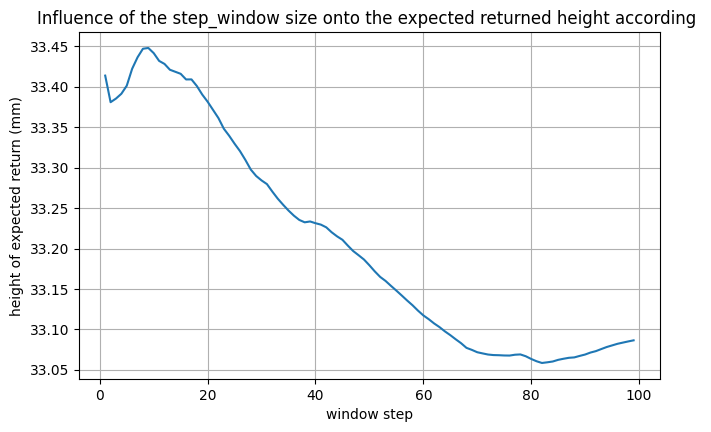

In [354]:
T=100
List_expected_waited_height=[]
for r in range(1,T):
    z_T_max=[]
    window_step = r
    for k in range(len(x)//T + 1):
        for l in range(r):
            if T*(k+1)+l<len(x):
                z_T_max.append(np.max(x[T*k+l:T*(k+1)+l]))
    expected_waited_height=np.mean(z_T_max)
    List_expected_waited_height.append(expected_waited_height)

    
print(List_expected_waited_height[-1])
plt.plot([r for r in range(1,T)],List_expected_waited_height)
plt.title("Influence of the step_window size onto the expected returned height according " )
plt.xlabel("window step")
plt.ylabel("height of expected return (mm)")
plt.show()



Now let's do a more sophisticated algorithm using the extreme value theory and the block maxima method seen in class.

We suppose here that the maximum of $X_i$ belongs to a domain of attraction $\gamma$. Then by using the definition of domain of attraction with sigma constant (fixed for t, here called beta) we get that $P(\frac{max_{i \in [1,window size]} X_i -b_n}{c_n} < \frac{z_T-b_n}{c_n}) = P(Z<\frac{z_T-b_n}{c_n}) $ where Z follows a GPD($\gamma$,1).

Hence;
$$(1-\frac{1}{T})^{window size} = (1- P( X_i > z_T) )^{window size} = (P( X_i < z_T) )^{window size} = P( max_{i \in [1,window size]} X_i < z_T) =  P(Z<\frac{z_T-b_n}{c_n}) $$


Let's solve 

$$
\begin{align*}
e^{-\left(1 + \gamma \frac{z_T - b_n}{c_n}\right)^{-1/\gamma}} &= (1-\frac{1}{T})^{window size}\\
(1-\frac{1}{T})^{window size} &= e^{-\left(1 + \gamma \frac{z_T - b_n}{c_n}\right)^{-1/\gamma}}\\
1 + \gamma \frac{z_T-b_n}{c_n} &= \left(-ln\left((1-\frac{1}{T})^{window size} \right) \right)^{-\gamma} \\
z_T &= b_n+\frac{c_n}{\gamma} \left[\left(-ln\left((1-\frac{1}{T})^{window size} \right)\right)^{-\gamma} - 1\right]
\end{align*}
$$




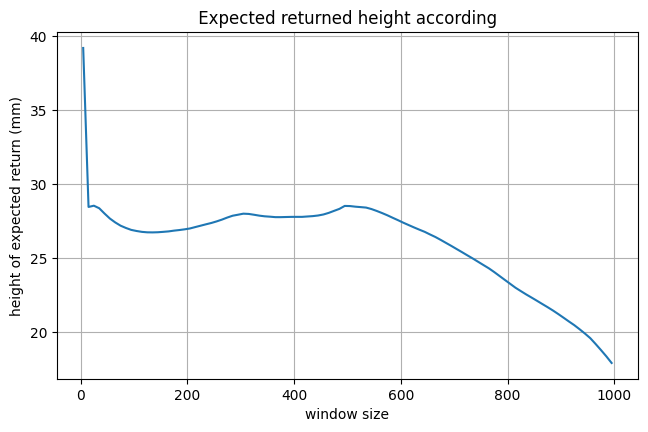

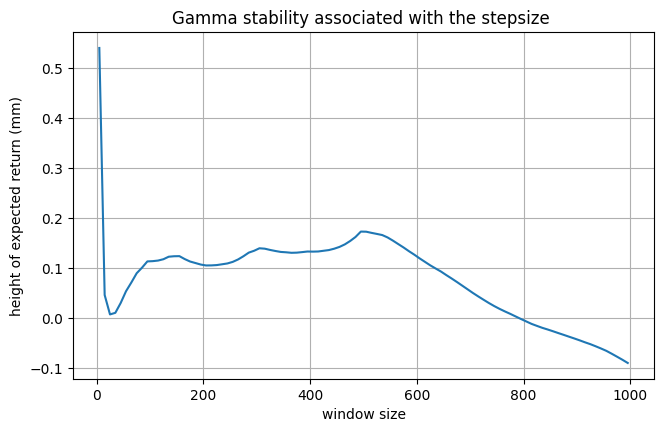

The estimated return level for 100 days in the stable domain is  27.595474603276383 mm
The estimated return level for 100 days where z has a plausible value (5<z<50) is  26.05126597445293 mm


In [355]:
from numpy import nan


T=100
parameter_max_window=10
gamma=[]

List_expected_waited_height=[]
for window_size in range(5,T*parameter_max_window,10):
   
    percentage = 100 * window_size / len(x)
    if abs(10 * window_size / len(x) - round(10 * window_size / len(x))) < 1e-10:
        print(f"{percentage:.1f}%")
    t=window_size
    
    z_T_max=[]
    r=window_size-1
    for k in range(len(x)//window_size + 1):
        for l in range(r):
            if window_size*(k+1)+l<len(x):
                z_T_max.append(np.max(x[window_size*k+l:window_size*(k+1)+l]))
    xi, u, beta = stats.genextreme.fit(z_T_max)
    xi=-xi
    # z_T = u + (beta/xi) *((-np.log(1-(1-1/T)**window_size))**(-xi)-1)
    z_T = u + (beta/xi) *((-np.log((1-1/T)**window_size))**(-xi)-1)
    gamma.append(xi)
    List_expected_waited_height.append(z_T)

    

plt.plot([window_size for window_size in range(5,T*parameter_max_window,10)],List_expected_waited_height)
plt.title(" Expected returned height according " )
plt.xlabel("window size")
plt.ylabel("height of expected return (mm)")
plt.show()


plt.plot([window_size for window_size in range(5,T*parameter_max_window,10)],gamma)
plt.title("Gamma stability associated with the stepsize " )
plt.xlabel("window size")
plt.ylabel("height of expected return (mm)")
plt.show()

print("The estimated return level for 100 days in the stable domain is ",np.mean(List_expected_waited_height[12:50]),"mm")
print("The estimated return level for 100 days where z has a plausible value (5<z<50) is ",np.mean([x for x in List_expected_waited_height if x > 5 and x < 50]),"mm")

On the first graph we clearly see a stable zone when we take the window_size between 70 and 310. This means that our window_size has to be taken between between 70 and 500. If window_size<70, then we cannot say that $\frac{max X_i - b_n}{c_n}$ (where n=window_size) follows a pareto law. If window_size>500, we do not have enough data to get good estimators of the pareto.

So we draw a second to see the stability of gamma and conclude which value we can keep, hence on this second graph we are more precised and see that we are stable for a window size between 120 and 500.
Hence by taking the mean over this choice we get $z_{T}$ = 27.5 mm, this matches with the naive block maxima method which estimates $z_T$ empirically.

We see that choosing the hyperparameter of the window size is like choosing the hyperparameter of the previous question whereas here it seems that we get a more stable zone. around 120 and 500 as a window size whereas for the threshold we clearly saw that to be in the extreme we had to be over 30 mm but to get a good estimator (stable) of $\gamma$ we needed to get more values so take a smaller threshold.
Hence here the block maxima method seems to be better, more stable.

### 2.D.2

In our case, the GPD method gives a higher return level than the Block Maxima method. This discrepancy can come from how sensitive the GPD is to the choice of threshold: if the selected threshold is too low, we include too many exceedances that are not truly extreme, which biases the tail upward and inflates the return level. This effect is visible in our data, where the tail is not very linear and the number of exceedances is relatively small, which affects the stability of the shape and scale parameters. By contrast, the Block Maxima method does not rely on a threshold and instead directly models maxima over fixed blocks, which in our case produced a more moderate return level. The fact that the GPD estimate lies between the naïve empirical estimation and the Block Maxima estimate also suggests that the GPD fit is partially affected by tail mis-specification. Overall, the gap between the two methods highlights that threshold choice in the GPD approach plays a role similar to block size choice in the Block Maxima framework: both can introduce bias if not selected carefully.

# Part 3

## 3.A

### 3.A.1

In [356]:
# Cellule 1 — Chargement des données Rdatasets (mêmes données que les packages R ismev/texmex)
import numpy as np

glassfiber = pd.read_csv("glassfiber.csv")

display(glassfiber.head())




,strength
0,0.55
1,0.74
2,0.77
3,0.81
4,0.84


### 3.A.2

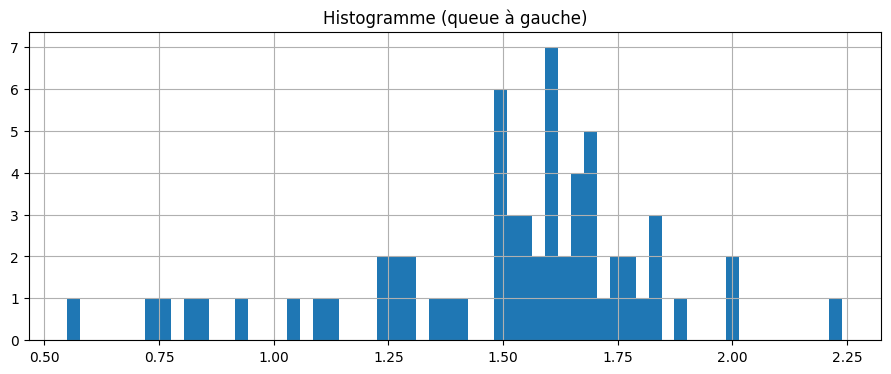

mean =  1.5068253968253966
median =  1.59
max =  2.24


In [357]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(11,4)) 
ax.hist(glassfiber, bins=60)
ax.set_title("Histogramme (queue à gauche)")
plt.show()
glassfiber=glassfiber.values
print("mean = ",np.mean(glassfiber))
print("median = ", np.median(glassfiber) )
print("max = ", np.max(glassfiber))

### 3.A.3

The minimum strength of a glassfiber must be greater than 0, this does not have any sense to talk abouth negative strength.

## 3.B

### 3.B.1

In [358]:
Y=-glassfiber
Y = Y.flatten()  
xi, mu, sigma = stats.genextreme.fit(Y) 
xi=-xi
print("xi = ", xi)
print("mu = ",mu)
print("sigma = ",sigma)

xi =  -0.08434058505446215
mu =  -1.6416124964088625
sigma =  0.27287370411045764


### 3.B.2

We find that $\hat{\xi}$ is negative, which aligns with the physical intuition that the distribution is bounded. This corresponds to a Weibull-type tail, indicating the presence of an upper endpoint. This conclusion is consistent with what we already anticipated in Question 3.A.3, where physical reasoning suggested that the distribution could not extend beyond 0 (so we could have induced it from this previous question directly).

## 3.C

### 3.C.1

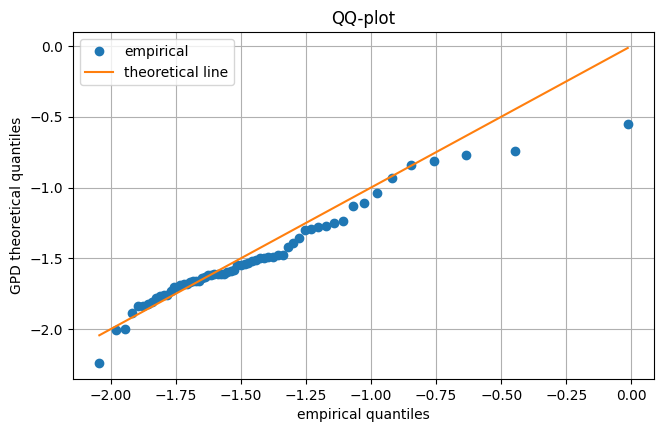

In [359]:
Y=np.sort(Y)
q=(np.arange(1, len(Y)+1) - 0.5) / len(Y)
gev_q = stats.genextreme.ppf(q, xi, loc=mu, scale=sigma)


plt.plot(gev_q,Y,'o',label="empirical")
plt.plot(gev_q,gev_q, label="theoretical line")
plt.xlabel("empirical quantiles")
plt.ylabel("GPD theoretical quantiles")
plt.title("QQ-plot")
plt.legend()
plt.show()


Here we see the limit of our modelisation using extreme balue theory. We see that our model match very well for value between -1.90 and -1.30 match a bit less beteen -1.30 and -0.75 and then does not mathc at all.

So if we want to be cautious we would place threshold between -1.90 and -1.30, since in this range we are in the extreme value "domain" and then if we want to relax a bit we can accept being between -1.90 and -0.75.

The deviance in the upper bound might be due to insufficient data in this zone so we cannot fit the right generalized pareto in this zone since we dont have enough data.

### 3.C.2

Supposing that X is in a domain of attraction $D_\gamma$ : 

$$1-p = P(Y<Q_{1-p}^{(Y)}) = P(\frac{Y-b_n}{c_n}<\frac{Q_{1-p}^{(Y)}-b_n}{c_n}) = e^{-\left(1 + \gamma \frac{Q_{1-p}^{(Y)} - b_n}{c_n}\right)^{-1/\gamma}} $$
hence we get $$ Q_{1-p}^{(Y)} = b_n+\frac{c_n}{\gamma} \left[\left(-ln\left(1-p \right)\right)^{-\gamma} - 1\right] $$
We deduce the quantile of X
$$q_p^{(X)} =-Q_{1-p}^{(Y)}=-b_n - \frac{c_n}{\gamma} \left[\left(-ln\left(1-p \right)\right)^{-\gamma} - 1\right]$$

In [360]:
xi, u, beta = stats.genextreme.fit(Y)
xi=-xi


for p in [0.01,0.005,0.001]:
    q = -u - (beta/xi) *((-np.log(1-p))**(-xi)-1)
    print("the value of quantile X for p = ",p," is ",q)

the value of quantile X for p =  0.01  is  0.6012002351455923
the value of quantile X for p =  0.005  is  0.47612106974597634
the value of quantile X for p =  0.001  is  0.2130822336783309


##### Sensivity of quantiles with respect to $\hat{\xi}$

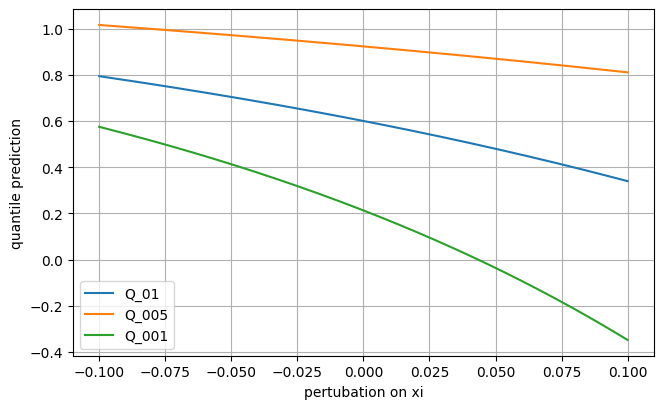

In [361]:
xi, u, beta = stats.genextreme.fit(Y)
xi=-xi
fixed_xi=xi.copy()
Q_01=[]
Q_005=[]
Q_001=[]
pertubation_bounds=0.1
L=np.linspace(-pertubation_bounds,pertubation_bounds,1000)



for delta in L:
    xi=delta+fixed_xi
    p=0.01
    q = -u - (beta/xi) *((-np.log(1-p))**(-xi)-1)
    Q_01.append(q)
    p=0.05
    q = -u - (beta/xi) *((-np.log(1-p))**(-xi)-1)
    Q_005.append(q)
    p=0.001
    q = -u - (beta/xi) *((-np.log(1-p))**(-xi)-1)
    Q_001.append(q)

plt.plot(L,Q_01, label="Q_01")
plt.plot(L,Q_005, label="Q_005")
plt.plot(L,Q_001, label = "Q_001")
plt.xlabel("pertubation on xi")
plt.ylabel("quantile prediction")
plt.legend()
plt.show()

We see that the more extreme is the quantile the more it is sensitive to $\hat{\xi}$. The slope around 0 of the quantile p=0.001 seems to be 4 times the slope of the quantile p=0.01. In other words, for the same error $\epsilon = \xi - \hat{\xi}$ leading to an error over the quantile p=0.01 $e_{01}= q( \xi )_{p = 0.01} - q(\hat{\xi}_{p = 0.01})$ and over the quantile p=0.001 $e_{001}= q( \xi )_{p = 0.001} - q(\hat{\xi})_{p = 0.001}$.

We will have $e_{001}=4*e_{01}$
Or we could see also this as IC the interval of confidence segment for $Q_{p = 0.01}^{(X)}$ would be eight times smaller than the interval of confidence of $Q_{p = 0.001}^{(X)}$.

This remark conforts us that in the intuition that the most extreme we are the most it will depend on the pareto distribution and hence our $\xi$ estimation.

## 3D

### 3D.1

Let 
$$
p(x,\theta) = p(x,\xi,\sigma,\mu) = \frac{1}{\sigma} t(x)^{\xi+1} e^{-t(x)}, \quad
t(x) = \begin{cases}
\left[ 1 + \xi \frac{x-\mu}{\sigma} \right]^{-1/\xi} & \text{if } \xi \neq 0\\[2mm]
\exp\left(-\frac{x-\mu}{\sigma}\right) & \text{if } \xi = 0
\end{cases}
$$

Log-density:
$$
\log p(x,\theta) = -\log\sigma + (\xi+1)\log t(x) - t(x)
$$

For a sample $(x_1,\dots,x_n)$:
$$
L(\theta) = \sum_{i=1}^n \log p(x_i, \theta)
$$

Parameter spaces:
$$
\Theta_1 = \{ (\mu,\sigma,\xi) \in \mathbb{R}^3 \}, \quad
\Theta_0 = \{ (\mu,\sigma,0) \in \mathbb{R}^3 \}
$$

Maximum likelihood estimates:
$$
\hat{\theta_0}=(\xi_0, \sigma_0, \mu_0) = \arg\max_{\theta \in \Theta_0} L(\theta), \quad
\hat{\theta_1}=(\xi_1, \sigma_1, \mu_1) = \arg\max_{\theta \in \Theta_1} L(\theta)
$$

The function genextreme gets the MLE so we get  $\hat{\theta_0}$ and $\hat{\theta_1}$ using it.
We get according to a statistical theorem  2*($L(\hat{\theta_1}) - L(\hat{\theta_0})$) follows a chi square law of dimension 1 = $3-2=dim(\Theta_1)-dim(\Theta_0)$

Let's take a look at our test, in theoretical sense we will accept the test iff $\theta_0=\theta_1$ we will more likely to reject the test if  $\theta_1-\theta_0$ is big enough, hence if T>K where K is a constant. 

Let's note $K=Q_{1-\alpha}$ where $Q_{1-\alpha}$ is the quantile of T (following a chi square law) associated with the significance level $\alpha$ : $P(\hat{T}<Q_{1-\alpha} | H_0 \quad is \quad True)= 1- \alpha$

We will get a risk that H_0 being rejecting whereas is true given by $P(\hat{T}>K | H_0 \quad is \quad True) = \alpha$ : we have probability alpha to do a false rejection.


In [362]:
xi_1, mu_1, beta_1 = stats.genextreme.fit(Y)



xi_0, mu_0, beta_0 = stats.genextreme.fit(Y, f0=0)


L_theta_1=[]
L_theta_0=[]

for y in Y:
    L_theta_1.append(np.log(stats.genextreme.pdf(y,xi_1, mu_1, beta_1)))
    L_theta_0.append(np.log(stats.genextreme.pdf(y,xi_0, mu_0, beta_0)))


T=2*(sum(L_theta_1)-sum(L_theta_0))



df = 3-2 # (dim(Theta_1)-dim(Theta_0))
alpha = 0.25 


 # significance level
chi2_crit = stats.chi2.ppf(1 - alpha, df)   

if T>chi2_crit:
    print("We reject H_0 with significance level, risk of false negative (rejection) of ", 100*alpha, "%")
else:
    print("We fail to reject H_0 with significance level, risk of false negative (rejection) of ", 100*alpha, "%")


    

We reject H_0 with significance level, risk of false negative (rejection) of  25.0 %


To go further, we could get the p-value computing:
  $$arginf_{\alpha \in [0,1]} P(\hat{T}>Q_{1-\alpha} | H_0 \quad is \quad True)$$

In [363]:
#Find the p statistic
alpha_max=0.99
alpha_min=0.01
alpha_mid=0.5
while alpha_max-alpha_min>1e-10:
    chi2_crit = stats.chi2.ppf(1 - alpha_mid, df) 
    
    if T>chi2_crit:
        alpha_max=alpha_mid
    else :
        alpha_min=alpha_mid
    alpha_mid=(alpha_max+alpha_min)/2

print("The p value here is", alpha_mid)
print("We can reject H_0 with a confidence of ",100*(1-alpha_mid), "%")

The p value here is 0.24676235421269666
We can reject H_0 with a confidence of  75.32376457873033 %


This result is consistent with the physical intuition we mentioned in part C: the tail is bounded, which implies that the endpoint of  X is finite. In other words, $X \in D_\xi$ with $\xi < 0$.

Moreover, based on our data and the likelihood ratio test, this intuition is statistically supported at the 75% confidence level.
